# GROUP PRACTICAL ASSIGNMENT: CURVE MODELING
**Course:** Geometric Modelling DIP  
**Group:** 1 — Road Path Modeling  
**Dataset:** OpenFlights Airports Dataset  
**Link:** https://raw.githubusercontent.com/jpatokal/openflights/master/data/airports.dat

In [1]:
# ============================================================
# IMPORT ALL REQUIRED LIBRARIES
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import splprep, splev

print('All libraries loaded successfully!')

All libraries loaded successfully!


---
## Step 1: Load Data

In [2]:
# ============================================================
# STEP 1: Load data from URL using pandas
# ============================================================

url = 'https://raw.githubusercontent.com/jpatokal/openflights/master/data/airports.dat'

# Assign column names (OpenFlights airports.dat format)
col_names = [
    'AirportID', 'Name', 'City', 'Country', 'IATA', 'ICAO',
    'Latitude', 'Longitude', 'Altitude', 'Timezone', 'DST',
    'TzDatabase', 'Type', 'Source'
]

df = pd.read_csv(url, header=None, names=col_names, na_values=['\\N'])

print(f'Dataset loaded successfully!')
print(f'Total records: {len(df)}')
print(f'\nFirst 5 rows:')
print(df[['Name', 'City', 'Country', 'Latitude', 'Longitude']].head())

# Extract Longitude and Latitude into x, y arrays
x = df['Longitude'].values
y = df['Latitude'].values

print(f'\nExtracted {len(x)} (Longitude, Latitude) coordinate pairs.')
print(f'Longitude range: [{x.min():.2f}, {x.max():.2f}]')
print(f'Latitude  range: [{y.min():.2f}, {y.max():.2f}]')

Dataset loaded successfully!
Total records: 7698

First 5 rows:
                                          Name          City  \
0                               Goroka Airport        Goroka   
1                               Madang Airport        Madang   
2                 Mount Hagen Kagamuga Airport   Mount Hagen   
3                               Nadzab Airport        Nadzab   
4  Port Moresby Jacksons International Airport  Port Moresby   

            Country  Latitude   Longitude  
0  Papua New Guinea -6.081690  145.391998  
1  Papua New Guinea -5.207080  145.789001  
2  Papua New Guinea -5.826790  144.296005  
3  Papua New Guinea -6.569803  146.725977  
4  Papua New Guinea -9.443380  147.220001  

Extracted 7698 (Longitude, Latitude) coordinate pairs.
Longitude range: [-179.88, 179.95]
Latitude  range: [-90.00, 89.50]


---
## Step 2: Data Cleaning

In [3]:
# ============================================================
# STEP 2: Data Cleaning
# ============================================================

print('--- Before Cleaning ---')
print(f'Total rows:      {len(df)}')
print(f'Missing values in Latitude:  {df["Latitude"].isna().sum()}')
print(f'Missing values in Longitude: {df["Longitude"].isna().sum()}')

# Remove missing values
df_clean = df[['Longitude', 'Latitude']].dropna()

# Remove duplicates
df_clean = df_clean.drop_duplicates()

print(f'\n--- After Cleaning ---')
print(f'Rows after dropna + drop_duplicates: {len(df_clean)}')

# Extract cleaned arrays
x_clean = df_clean['Longitude'].values
y_clean = df_clean['Latitude'].values

# Normalize coordinates using min-max scaling
x_norm = (x_clean - x_clean.min()) / (x_clean.max() - x_clean.min())
y_norm = (y_clean - y_clean.min()) / (y_clean.max() - y_clean.min())

print(f'\n--- After Normalization (min-max) ---')
print(f'x range: [{x_norm.min():.4f}, {x_norm.max():.4f}]')
print(f'y range: [{y_norm.min():.4f}, {y_norm.max():.4f}]')

print()
print('Why normalization is important:')
print('  Longitude ranges from -180 to +180 and Latitude from -90 to +90.')
print('  These different scales can distort distance calculations and')
print('  curve fitting. Normalization maps all values to [0, 1], making')
print('  the data scale-independent and improving numerical stability')
print('  in polynomial fitting and interpolation algorithms.')

--- Before Cleaning ---
Total rows:      7698
Missing values in Latitude:  0
Missing values in Longitude: 0

--- After Cleaning ---
Rows after dropna + drop_duplicates: 7698

--- After Normalization (min-max) ---
x range: [0.0000, 1.0000]
y range: [0.0000, 1.0000]

Why normalization is important:
  Longitude ranges from -180 to +180 and Latitude from -90 to +90.
  These different scales can distort distance calculations and
  curve fitting. Normalization maps all values to [0, 1], making
  the data scale-independent and improving numerical stability
  in polynomial fitting and interpolation algorithms.


---
## Step 3: Visualization

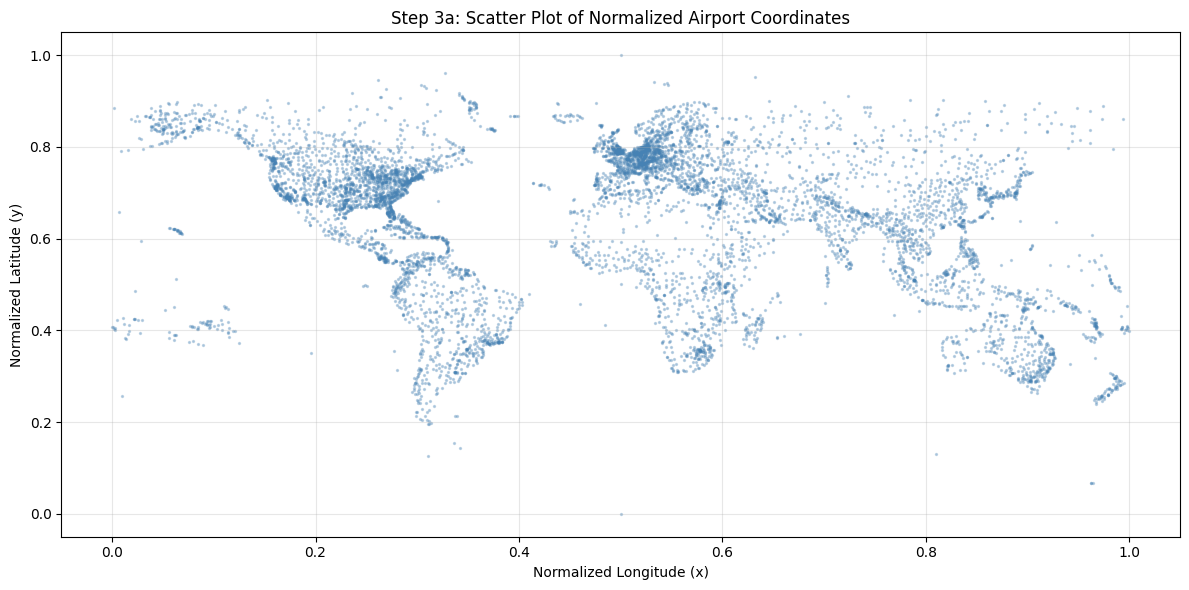

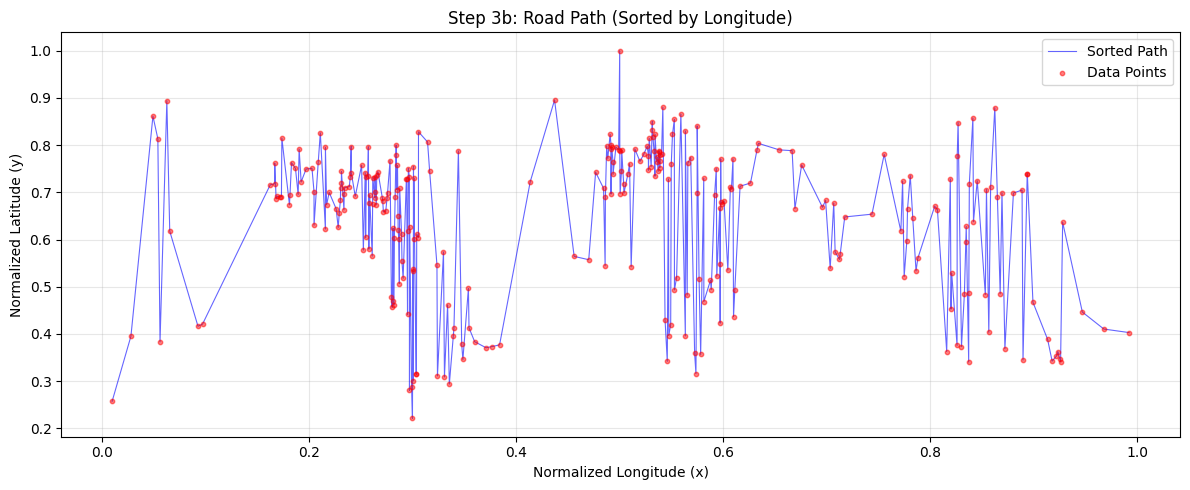

Observations:
  - The scatter plot shows global airport distribution.
  - Sorting by x (longitude) creates a west-to-east path.
  - Noise: many airports at similar longitudes cause vertical jumps.
  - Sharp turns: visible where latitude changes abruptly between
    adjacent longitude-sorted airports (different continents).


In [4]:
# ============================================================
# STEP 3: Visualization
# ============================================================

# --- 3a: Scatter plot of all coordinates ---
plt.figure(figsize=(12, 6))
plt.scatter(x_norm, y_norm, s=2, alpha=0.3, color='steelblue')
plt.title('Step 3a: Scatter Plot of Normalized Airport Coordinates')
plt.xlabel('Normalized Longitude (x)')
plt.ylabel('Normalized Latitude (y)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 3b: Sort by x to create a path and plot it ---
# Take a sample of 300 points for cleaner path visualization
sample_size = 300
np.random.seed(42)
sample_idx = np.random.choice(len(x_norm), sample_size, replace=False)
x_sample = x_norm[sample_idx]
y_sample = y_norm[sample_idx]

# Sort by x to form a path
sort_order = np.argsort(x_sample)
x_path = x_sample[sort_order]
y_path = y_sample[sort_order]

plt.figure(figsize=(12, 5))
plt.plot(x_path, y_path, 'b-', linewidth=0.8, alpha=0.6, label='Sorted Path')
plt.scatter(x_path, y_path, s=10, color='red', zorder=5, alpha=0.5, label='Data Points')
plt.title('Step 3b: Road Path (Sorted by Longitude)')
plt.xlabel('Normalized Longitude (x)')
plt.ylabel('Normalized Latitude (y)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Observations:')
print('  - The scatter plot shows global airport distribution.')
print('  - Sorting by x (longitude) creates a west-to-east path.')
print('  - Noise: many airports at similar longitudes cause vertical jumps.')
print('  - Sharp turns: visible where latitude changes abruptly between')
print('    adjacent longitude-sorted airports (different continents).')

---
## Step 4: Analytical Curve — Polynomial Fitting

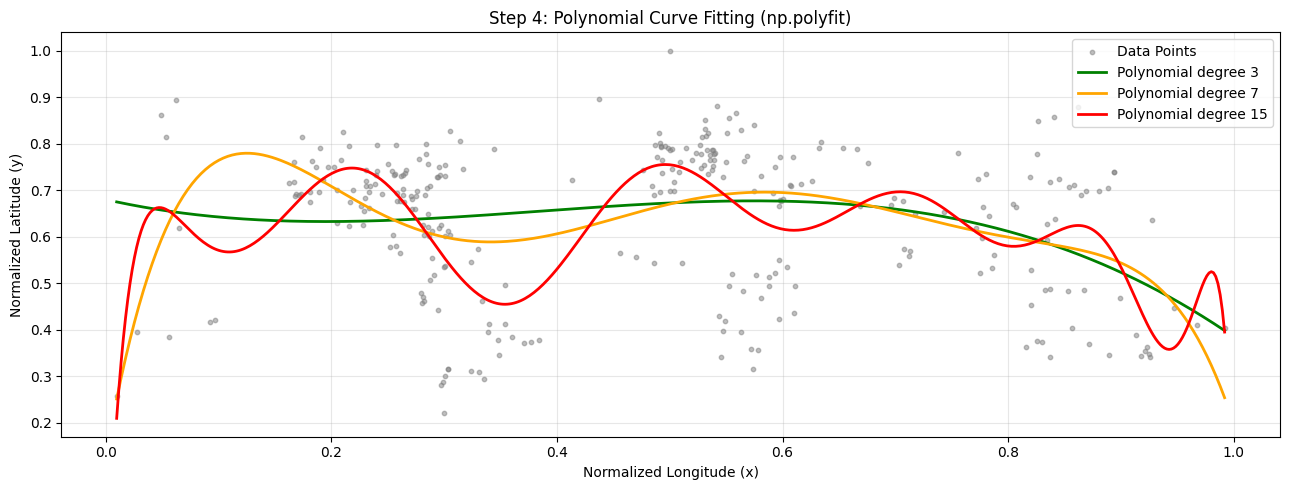

Observations:
  - Degree 3:  Smooth but underfits — misses many data points.
  - Degree 7:  Better fit in the middle but starts to wiggle at edges.
  - Degree 15: Severe overfitting — extreme unrealistic bends at
    the boundaries (Runge phenomenon). Not suitable for road paths.


In [5]:
# ============================================================
# STEP 4: Analytical Curve — Polynomial using np.polyfit()
# ============================================================

# Use the sorted path data from Step 3
degrees = [3, 7, 15]  # low, medium, high degree polynomials
x_line = np.linspace(x_path.min(), x_path.max(), 500)

plt.figure(figsize=(13, 5))
plt.scatter(x_path, y_path, s=10, color='gray', alpha=0.5, zorder=2, label='Data Points')

colors = ['green', 'orange', 'red']
for deg, col in zip(degrees, colors):
    coeffs = np.polyfit(x_path, y_path, deg)
    poly   = np.poly1d(coeffs)
    y_fit  = poly(x_line)
    plt.plot(x_line, y_fit, color=col, linewidth=2,
             label=f'Polynomial degree {deg}')

plt.title('Step 4: Polynomial Curve Fitting (np.polyfit)')
plt.xlabel('Normalized Longitude (x)')
plt.ylabel('Normalized Latitude (y)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Observations:')
print('  - Degree 3:  Smooth but underfits — misses many data points.')
print('  - Degree 7:  Better fit in the middle but starts to wiggle at edges.')
print('  - Degree 15: Severe overfitting — extreme unrealistic bends at')
print('    the boundaries (Runge phenomenon). Not suitable for road paths.')

---
## Step 5: Bézier Curve

Control points selected: 10
  P0: (0.0095, 0.2573)
  P1: (0.2192, 0.6998)
  P2: (0.2652, 0.7368)
  P3: (0.2966, 0.7325)
  P4: (0.3768, 0.3734)
  P5: (0.5265, 0.7978)
  P6: (0.5633, 0.8300)
  P7: (0.6339, 0.8037)
  P8: (0.8301, 0.3734)
  P9: (0.9921, 0.4029)


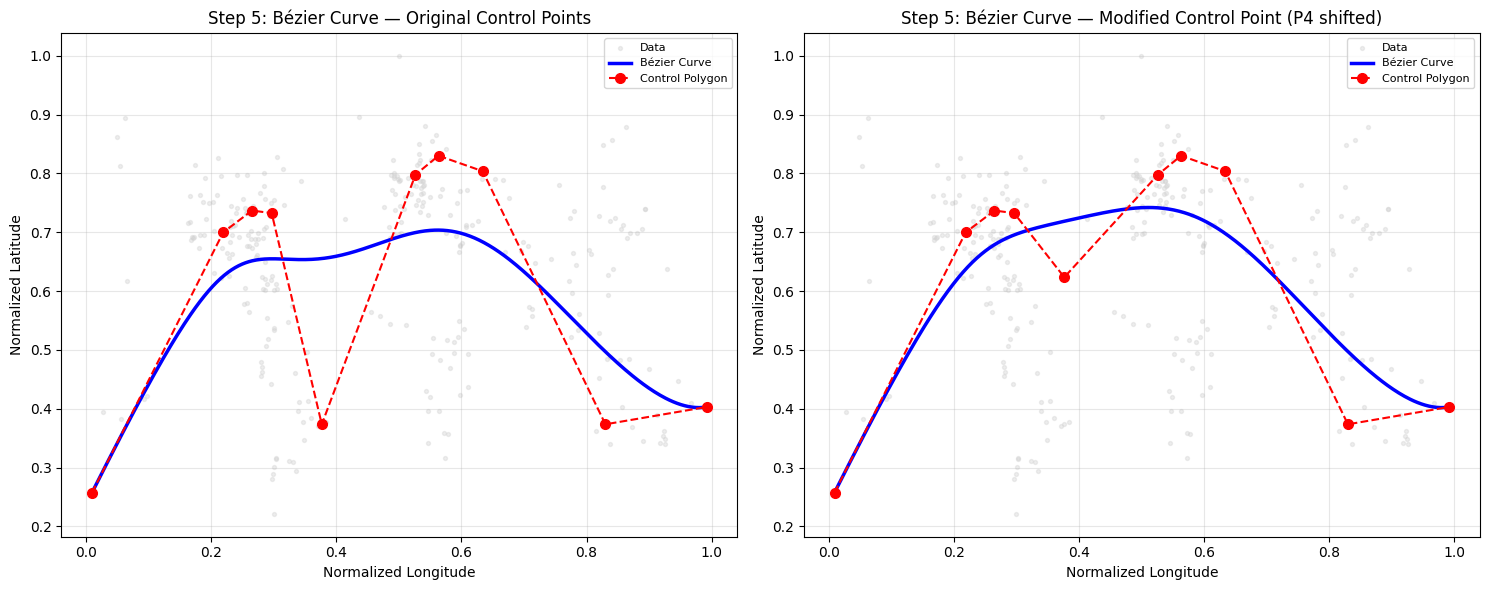


Observation — Global Effect:
  Moving a single control point (P4) changes the ENTIRE curve.
  This is the global nature of Bézier curves — every control
  point influences every point on the curve. Not ideal for
  local edits in road design.


In [6]:
# ============================================================
# STEP 5: Bézier Curve — De Casteljau Algorithm
# ============================================================

def de_casteljau(control_points, t):
    """
    Evaluate a Bezier curve at parameter t using De Casteljau's algorithm.
    control_points: list of (x, y) tuples
    t: float in [0, 1]
    Returns: (x, y) point on the curve
    """
    pts = np.array(control_points, dtype=float)
    n = len(pts)
    while n > 1:
        pts = (1 - t) * pts[:-1] + t * pts[1:]
        n -= 1
    return pts[0]

def bezier_curve(control_points, num_points=500):
    """Generate Bezier curve points for plotting."""
    t_vals = np.linspace(0, 1, num_points)
    curve  = np.array([de_casteljau(control_points, t) for t in t_vals])
    return curve

# --- Select control points from sampled data ---
# Sample every ~30th point from sorted path for clean control polygon
ctrl_indices = np.linspace(0, len(x_path)-1, 10, dtype=int)
ctrl_pts = list(zip(x_path[ctrl_indices], y_path[ctrl_indices]))

print(f'Control points selected: {len(ctrl_pts)}')
for i, pt in enumerate(ctrl_pts):
    print(f'  P{i}: ({pt[0]:.4f}, {pt[1]:.4f})')

# Generate Bezier curve
bezier_pts = bezier_curve(ctrl_pts)

# --- Plot Bezier curve and control polygon ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Original control polygon
ctrl_arr = np.array(ctrl_pts)
for ax, title_suffix in zip(axes, ['Original Control Points', 'Modified Control Point (P4 shifted)']):
    ax.scatter(x_path, y_path, s=8, color='lightgray', alpha=0.4, label='Data')
    ax.plot(bezier_pts[:, 0], bezier_pts[:, 1], 'b-', linewidth=2.5,
            label='Bézier Curve', zorder=3)
    ax.plot(ctrl_arr[:, 0], ctrl_arr[:, 1], 'r--o', linewidth=1.5,
            markersize=7, label='Control Polygon', zorder=4)
    ax.set_xlabel('Normalized Longitude'); ax.set_ylabel('Normalized Latitude')
    ax.set_title(f'Step 5: Bézier Curve — {title_suffix}')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    # Modify control point for second plot
    ctrl_arr[4, 1] += 0.25  # shift P4 upward
    bezier_pts = bezier_curve(ctrl_arr.tolist())

plt.tight_layout()
plt.show()

print()
print('Observation — Global Effect:')
print('  Moving a single control point (P4) changes the ENTIRE curve.')
print('  This is the global nature of Bézier curves — every control')
print('  point influences every point on the curve. Not ideal for')
print('  local edits in road design.')

---
## Step 6: B-Spline Curve

B-Spline fitted successfully!
Smoothing factor (s): 0.5
Degree (k): 3 (cubic)
Number of knots: 135


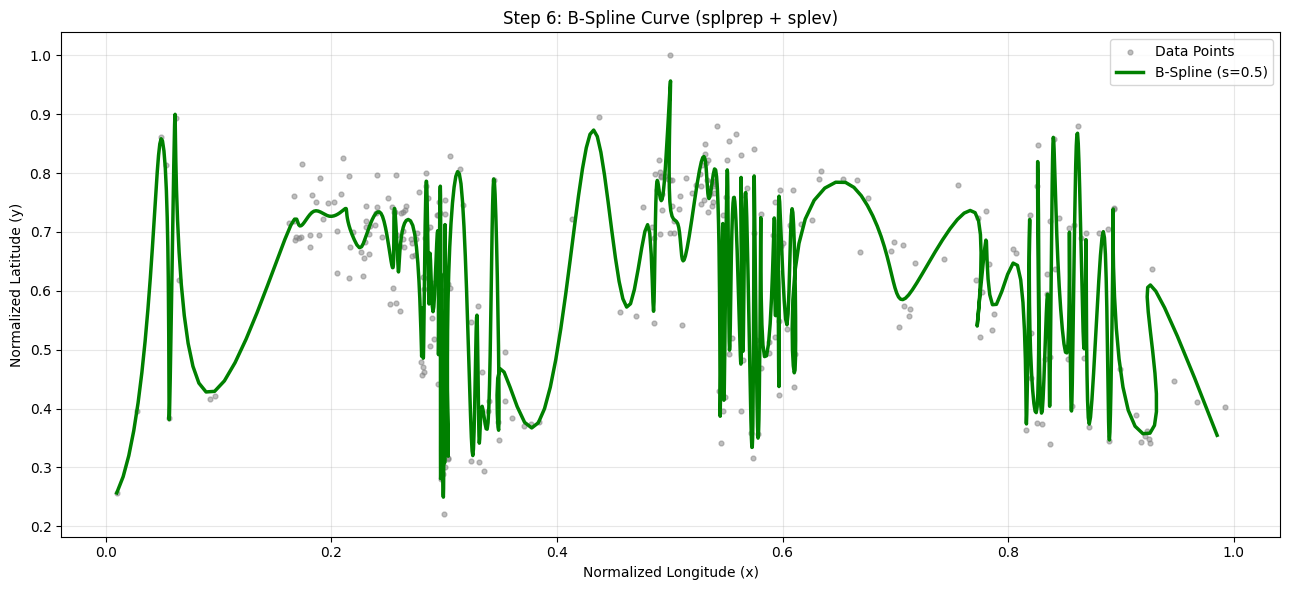

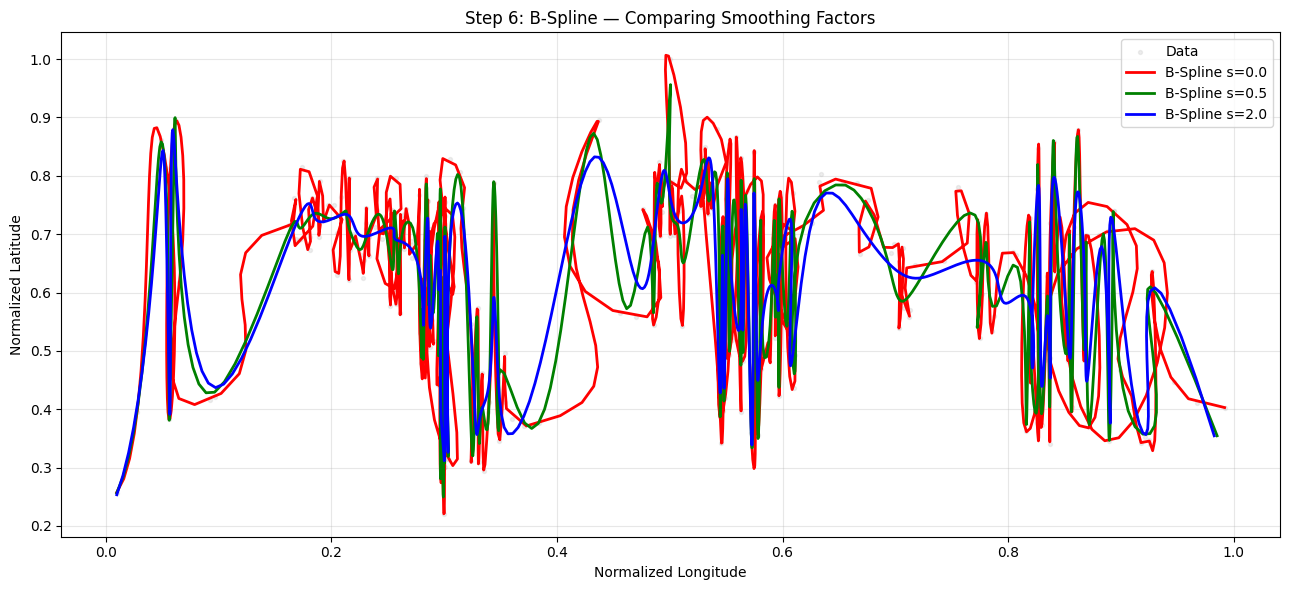


Observation:
  s=0.0 interpolates every point (wiggly, follows noise).
  s=0.5 gives a smooth curve that approximates the general path.
  s=2.0 over-smooths — loses detail but very clean road-like curve.


In [7]:
# ============================================================
# STEP 6: B-Spline Curve using splprep() and splev()
# ============================================================

from scipy.interpolate import splprep, splev

# Use the sorted path data — take a clean subset to avoid splprep issues
# Remove duplicate x values for stable fitting
_, unique_idx = np.unique(x_path, return_index=True)
x_unique = x_path[unique_idx]
y_unique = y_path[unique_idx]

# Fit B-Spline using splprep
# s = smoothing factor (0 = interpolate all points, higher = smoother)
tck, u = splprep([x_unique, y_unique], s=0.5, k=3)  # cubic B-spline

# Evaluate the spline at fine resolution
u_fine = np.linspace(0, 1, 1000)
x_spline, y_spline = splev(u_fine, tck)

print('B-Spline fitted successfully!')
print(f'Smoothing factor (s): 0.5')
print(f'Degree (k): 3 (cubic)')
print(f'Number of knots: {len(tck[0])}')

# --- Plot B-Spline vs original data ---
plt.figure(figsize=(13, 6))
plt.scatter(x_unique, y_unique, s=12, color='gray', alpha=0.5, zorder=2, label='Data Points')
plt.plot(x_spline, y_spline, 'green', linewidth=2.5, zorder=3, label='B-Spline (s=0.5)')
plt.title('Step 6: B-Spline Curve (splprep + splev)')
plt.xlabel('Normalized Longitude (x)')
plt.ylabel('Normalized Latitude (y)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Compare smoothing factors ---
smoothing_factors = [0.0, 0.5, 2.0]
s_colors = ['red', 'green', 'blue']

plt.figure(figsize=(13, 6))
plt.scatter(x_unique, y_unique, s=8, color='lightgray', alpha=0.4, zorder=1, label='Data')

for s_val, col in zip(smoothing_factors, s_colors):
    tck_s, _ = splprep([x_unique, y_unique], s=s_val, k=3)
    xs, ys   = splev(u_fine, tck_s)
    plt.plot(xs, ys, color=col, linewidth=2, label=f'B-Spline s={s_val}')

plt.title('Step 6: B-Spline — Comparing Smoothing Factors')
plt.xlabel('Normalized Longitude'); plt.ylabel('Normalized Latitude')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print('\nObservation:')
print('  s=0.0 interpolates every point (wiggly, follows noise).')
print('  s=0.5 gives a smooth curve that approximates the general path.')
print('  s=2.0 over-smooths — loses detail but very clean road-like curve.')

---
## Step 7: Evaluation — Compare Polynomial, Bézier, and B-Spline

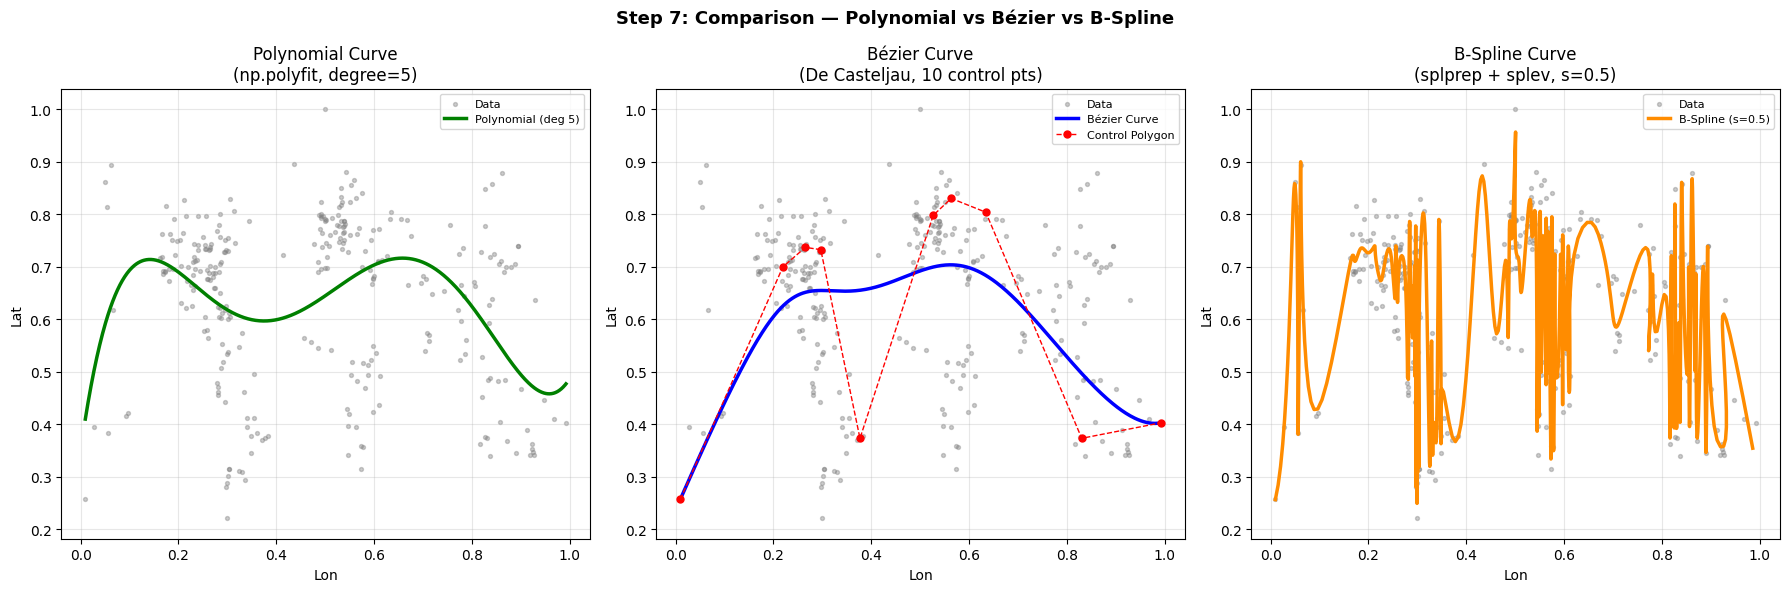

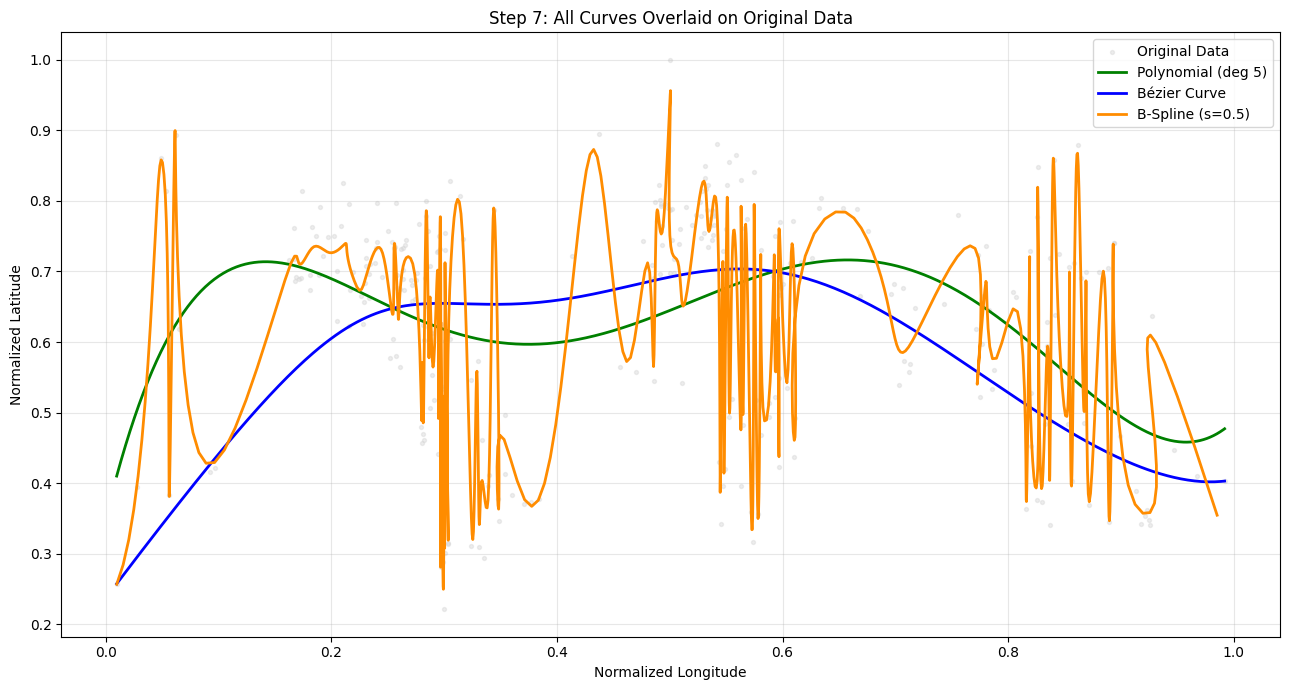

STEP 7: EVALUATION SUMMARY

1. POLYNOMIAL CURVE (np.polyfit):
   Smoothness: Moderate — smooth in the middle, extreme
   oscillations at boundaries (Runge phenomenon at high degree).
   Realism: Low — global curve cannot handle sharp local turns.
   Road Design: Poor. A single global polynomial cannot model
   realistic multi-segment road paths.

2. BÉZIER CURVE (De Casteljau):
   Smoothness: Very smooth — guaranteed C0 and C1 continuity.
   Realism: Moderate — follows control polygon but does not
   pass through data points; global influence of all control pts.
   Road Design: Useful for simple curved road segments.
   Limitation: Changing one control point affects entire curve.

3. B-SPLINE CURVE (splprep/splev):
   Smoothness: Excellent — piecewise smooth, local control.
   Realism: Highest — fits complex paths without overfitting.
   Road Design: Best choice. Local edits only affect nearby
   sections. Smoothing factor controls noise tolerance.
   Impact on Traffic: Smooth B-spline

In [8]:
# ============================================================
# STEP 7: Evaluation — Compare all three curve types
# ============================================================

# Recompute all curves on the same data for fair comparison
x_eval = x_unique
y_eval = y_unique
x_line_eval = np.linspace(x_eval.min(), x_eval.max(), 1000)

# Polynomial (degree 5 — balanced)
coeffs5 = np.polyfit(x_eval, y_eval, 5)
poly5   = np.poly1d(coeffs5)
y_poly  = poly5(x_line_eval)

# Bezier (reset to original control points)
ctrl_indices2 = np.linspace(0, len(x_eval)-1, 10, dtype=int)
ctrl_pts2 = list(zip(x_eval[ctrl_indices2], y_eval[ctrl_indices2]))
bezier_eval = bezier_curve(ctrl_pts2)

# B-Spline (s=0.5)
tck_eval, _ = splprep([x_eval, y_eval], s=0.5, k=3)
x_bsp, y_bsp = splev(np.linspace(0, 1, 1000), tck_eval)

# --- Side-by-side comparison plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Step 7: Comparison — Polynomial vs Bézier vs B-Spline', fontsize=13, fontweight='bold')

# Polynomial
axes[0].scatter(x_eval, y_eval, s=8, color='gray', alpha=0.4, label='Data')
axes[0].plot(x_line_eval, y_poly, 'green', linewidth=2.5, label='Polynomial (deg 5)')
axes[0].set_title('Polynomial Curve\n(np.polyfit, degree=5)')
axes[0].set_xlabel('Lon'); axes[0].set_ylabel('Lat')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

# Bezier
ctrl_arr2 = np.array(ctrl_pts2)
axes[1].scatter(x_eval, y_eval, s=8, color='gray', alpha=0.4, label='Data')
axes[1].plot(bezier_eval[:, 0], bezier_eval[:, 1], 'blue', linewidth=2.5, label='Bézier Curve')
axes[1].plot(ctrl_arr2[:, 0], ctrl_arr2[:, 1], 'r--o', linewidth=1, markersize=5, label='Control Polygon')
axes[1].set_title('Bézier Curve\n(De Casteljau, 10 control pts)')
axes[1].set_xlabel('Lon'); axes[1].set_ylabel('Lat')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

# B-Spline
axes[2].scatter(x_eval, y_eval, s=8, color='gray', alpha=0.4, label='Data')
axes[2].plot(x_bsp, y_bsp, 'darkorange', linewidth=2.5, label='B-Spline (s=0.5)')
axes[2].set_title('B-Spline Curve\n(splprep + splev, s=0.5)')
axes[2].set_xlabel('Lon'); axes[2].set_ylabel('Lat')
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Overlay comparison ---
plt.figure(figsize=(13, 7))
plt.scatter(x_eval, y_eval, s=8, color='lightgray', alpha=0.4, label='Original Data')
plt.plot(x_line_eval, y_poly,          'green',      linewidth=2,   label='Polynomial (deg 5)')
plt.plot(bezier_eval[:, 0], bezier_eval[:, 1], 'blue', linewidth=2, label='Bézier Curve')
plt.plot(x_bsp, y_bsp,                'darkorange',  linewidth=2,   label='B-Spline (s=0.5)')
plt.title('Step 7: All Curves Overlaid on Original Data')
plt.xlabel('Normalized Longitude'); plt.ylabel('Normalized Latitude')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Written Evaluation ---
print('=' * 65)
print('STEP 7: EVALUATION SUMMARY')
print('=' * 65)
print()
print('1. POLYNOMIAL CURVE (np.polyfit):')
print('   Smoothness: Moderate — smooth in the middle, extreme')
print('   oscillations at boundaries (Runge phenomenon at high degree).')
print('   Realism: Low — global curve cannot handle sharp local turns.')
print('   Road Design: Poor. A single global polynomial cannot model')
print('   realistic multi-segment road paths.')
print()
print('2. BÉZIER CURVE (De Casteljau):')
print('   Smoothness: Very smooth — guaranteed C0 and C1 continuity.')
print('   Realism: Moderate — follows control polygon but does not')
print('   pass through data points; global influence of all control pts.')
print('   Road Design: Useful for simple curved road segments.')
print('   Limitation: Changing one control point affects entire curve.')
print()
print('3. B-SPLINE CURVE (splprep/splev):')
print('   Smoothness: Excellent — piecewise smooth, local control.')
print('   Realism: Highest — fits complex paths without overfitting.')
print('   Road Design: Best choice. Local edits only affect nearby')
print('   sections. Smoothing factor controls noise tolerance.')
print('   Impact on Traffic: Smooth B-spline roads reduce sharp turns,')
print('   improving vehicle flow, safety, and fuel efficiency.')
print()
print('CONCLUSION: B-Spline is the most suitable for road path modeling')
print('due to local control, smoothness, and realistic curve behavior.')
print('=' * 65)